## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 100)

%matplotlib inline

In [2]:
DATA_PATH = Path('../../claim_use_case_dataset.xlsx')
df_raw = pd.read_excel(DATA_PATH, engine='openpyxl')
print(f'Dataset shape: {df_raw.shape}')
df_raw.head()

Dataset shape: (2880, 35)


,excessFee,rrp,balanceRRP,oldBalanceRRP,productName,productDesc,coverage,productCode,policyStartDate,policyEndDate,policyStatus,retailerName,deviceType,make,model,purchaseDate,deviceCost,relationship,channel,claimType,country,status,turnOnOff,touchScreen,smashed,frontCamera,backCamera,frontOrBackCamera,audio,mic,buttons,connection,charging,other,issueDesc
0,1989.0,11990.0,11990.0,11990.0,SE_ADLD+THEFT_12M_MONTHLY_SMARTPHONE,"WUAWEI Care+ Otursskador, vÃƒÂ¤tskeskador och stÃƒÂ¶ld",ADLD/THEFT,SEADLDTHEFT12,2022-04-01 00:00:00,2023-04-01 00:00:00,Active,WUAWEI eStore,NaN,WUAWEI,WUAWEI-AAA1,2022-04-01 00:00:00,0,self,Online Portal,Theft,SE,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,***** gÃ¥ngen *** **** mobilen var nÃ¤r *** var pÃ¥ toaletten kl ***** nÃ¥gongÃ¥ng. Efter ***** ...
1,619.0,15490.0,15490.0,15490.0,SE_MANDATORY_ADLD_12M_UPFRONT_SMARTPHONE,WUAWEI Care+ Otursskador och vÃƒÂ¤tskeskador,ADLD,SEADLD1206,28/02/2022,28/02/2023,Active,SWEDEN ESTORE BULK UPLOAD,NaN,WUAWEI,WUAWEI-AAA2,2022-03-03 00:00:00,0,self,Online Portal,Accidental Damage,SE,Completed,1.0,1.0,NaN,1.0,1.0,NaN,1.0,1.0,0.0,NaN,NaN,NaN,*** tog telefonen frÃ¥n ***** nÃ¤r *** skulle kliva ur och *** slant nÃ¤r *** skulle stoppa *** ...
2,2509.0,19490.0,19490.0,19490.0,SE_ADLD+THEFT_12M_MONTHLY_SMARTPHONE,"WUAWEI Care+ Otursskador, vÃƒÂ¤tskeskador och stÃƒÂ¶ld",ADLD/THEFT,SEADLDTHEFT12,2022-04-01 00:00:00,2023-04-01 00:00:00,Active,WUAWEI eStore,NaN,WUAWEI,WUAWEI-AAA3,2022-04-01 00:00:00,0,self,Online Portal,Theft,SE,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"*** och *** ***** var pÃ¥ semester i **** och blev bestulna pÃ¥ vÃ¥ra pass, **** och telefoner. ..."
3,619.0,15490.0,15490.0,15490.0,SE_MANDATORY_ADLD_12M_UPFRONT_SMARTPHONE,WUAWEI Care+ Otursskador och vÃƒÂ¤tskeskador,ADLD,SEADLD1206,28/02/2022,28/02/2023,Active,SWEDEN ESTORE BULK UPLOAD,NaN,WUAWEI,WUAWEI-AAA4,2022-03-03 00:00:00,0,self,Online Portal,Accidental Damage,SE,Completed,1.0,1.0,NaN,1.0,1.0,NaN,1.0,1.0,0.0,NaN,NaN,NaN,- **** upptÃ¤ckte *** en 8mm **** horisontal spricka/repa i glaset vid en av de stora bakre kame...
4,619.0,14490.0,14490.0,14490.0,SE_ADLD_24M_UPFRONT_SMARTPHONE,WUAWEI Care+ Otursskador och vÃ¤tskeskador,ADLD,SEADLD24,17/02/2022,17/02/2024,Active,WUAWEI eStore,NaN,WUAWEI,WUAWEI-AAA5,18/02/2022,0,self,Phone Call,Accidental Damage,SE,Completed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,He wanted to attach the Childs wagon and his phone fall to the ground he had cover and protector...


---
## 2. Initial Data Overview

In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2880 entries, 0 to 2879
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   excessFee          2874 non-null   float64
 1   rrp                2880 non-null   float64
 2   balanceRRP         2880 non-null   float64
 3   oldBalanceRRP      2880 non-null   float64
 4   productName        2880 non-null   str    
 5   productDesc        2880 non-null   str    
 6   coverage           2880 non-null   str    
 7   productCode        2877 non-null   str    
 8   policyStartDate    2880 non-null   object 
 9   policyEndDate      2880 non-null   object 
 10  policyStatus       2880 non-null   str    
 11  retailerName       2519 non-null   str    
 12  deviceType         1486 non-null   str    
 13  make               2877 non-null   str    
 14  model              2880 non-null   str    
 15  purchaseDate       2880 non-null   object 
 16  deviceCost         2880 non-null   

In [4]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
excessFee,2874.0,NaN,NaN,NaN,387.070633,446.548065,0.0,59.0,139.0,619.0,3629.0
rrp,2880.0,NaN,NaN,NaN,6926.282556,7300.148073,0.0,1349.0,1799.0,14490.0,43888.0
balanceRRP,2880.0,NaN,NaN,NaN,6781.947028,7214.160287,-4861.33,1349.0,1799.0,13990.0,43888.0
oldBalanceRRP,2880.0,NaN,NaN,NaN,6781.947028,7214.160287,-4861.33,1349.0,1799.0,13990.0,43888.0
productName,2880,134,SE_ADLD_24M_UPFRONT_SMARTPHONE,288,NaN,NaN,NaN,NaN,NaN,NaN,NaN
productDesc,2880,16,WUAWEI Care+ Onopzettelijke Schade en Vloeistofschade,910,NaN,NaN,NaN,NaN,NaN,NaN,NaN
coverage,2880,2,ADLD,2211,NaN,NaN,NaN,NaN,NaN,NaN,NaN
productCode,2877,132,SEADLD24,287,NaN,NaN,NaN,NaN,NaN,NaN,NaN
policyStartDate,2880,676,28/02/2022,84,NaN,NaN,NaN,NaN,NaN,NaN,NaN
policyEndDate,2880,716,28/02/2023,77,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Missing values summary
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('pct', ascending=False)
print(f'Columns with missing values: {len(missing_df)} / {len(df_raw.columns)}')
missing_df

Columns with missing values: 17 / 35


,count,pct
other,2235,77.60
frontOrBackCamera,1877,65.17
smashed,1877,65.17
deviceType,1394,48.40
charging,677,23.51
connection,677,23.51
retailerName,361,12.53
mic,222,7.71
frontCamera,222,7.71
backCamera,222,7.71


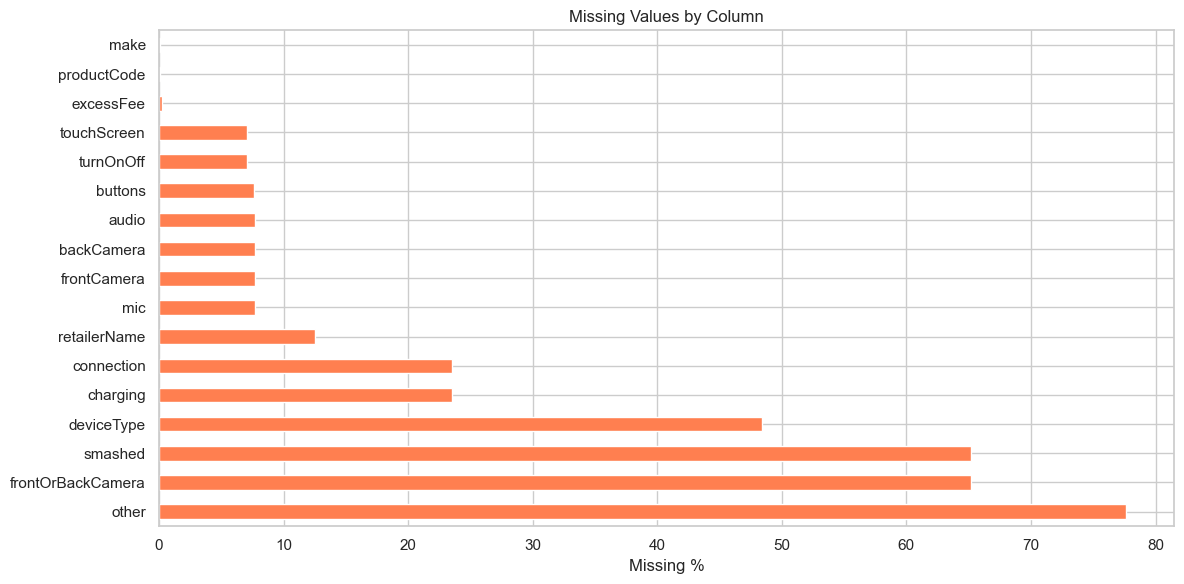

In [6]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(12, 6))
missing_df['pct'].plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column')
plt.tight_layout()
plt.show()

---
## 3. Target Variable Analysis

Target distribution:
status
Completed    2427
Declined      453
Name: count, dtype: int64

Declined rate: 15.73%


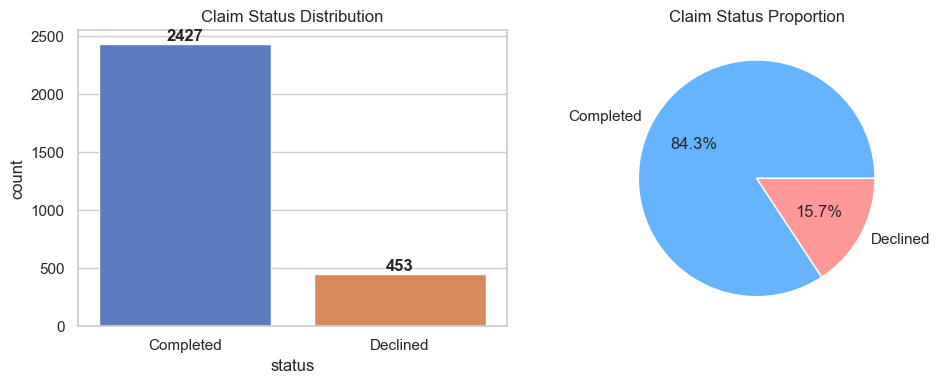

In [7]:
print('Target distribution:')
print(df_raw['status'].value_counts())
print(f'\nDeclined rate: {(df_raw["status"] == "Declined").mean():.2%}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
sns.countplot(x='status', data=df_raw, ax=axes[0], hue='status', legend=False)
axes[0].set_title('Claim Status Distribution')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Pie chart
df_raw['status'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1], colors=['#66b3ff', '#ff9999'])
axes[1].set_ylabel('')
axes[1].set_title('Claim Status Proportion')

plt.tight_layout()
plt.show()

**Observation:** The dataset is imbalanced — ~84% Completed vs ~16% Declined. We'll need to account for this during modelling (e.g., class weights, SMOTE, stratified splits).

---
## 4. Categorical Feature Analysis

In [8]:
cat_cols = ['coverage', 'productCode', 'policyStatus', 'retailerName', 'deviceType',
            'make', 'relationship', 'channel', 'claimType', 'country']

for col in cat_cols:
    print(f'\n--- {col} ---')
    print(df_raw[col].value_counts(dropna=False))


--- coverage ---
coverage
ADLD          2211
ADLD/THEFT     669
Name: count, dtype: int64

--- productCode ---
productCode
SEADLD24           287
NLADLD1240         279
SEADLD6            222
NLADLD1247         155
NLADLD1212         147
                  ... 
FIADLDTHEFT2401      1
FIADLD1232           1
FIADLD1226           1
FIADLD1225           1
FIADLD1224           1
Name: count, Length: 133, dtype: int64

--- policyStatus ---
policyStatus
Active          2849
Grace Period      28
InActive           3
Name: count, dtype: int64

--- retailerName ---
retailerName
WUAWEI eStore                 1797
WUAWEI SCPUserPortal           380
NaN                            361
SWEDEN ESTORE BULK UPLOAD      204
PSFM RETAIL ELECTRONICS         70
FINLAND ESTORE BULK UPLOAD      40
EVOLLIS                         21
BREDA SES                        4
bolttech D2C                     2
UTRECHT SES                      1
Name: count, dtype: int64

--- deviceType ---
deviceType
NaN            139

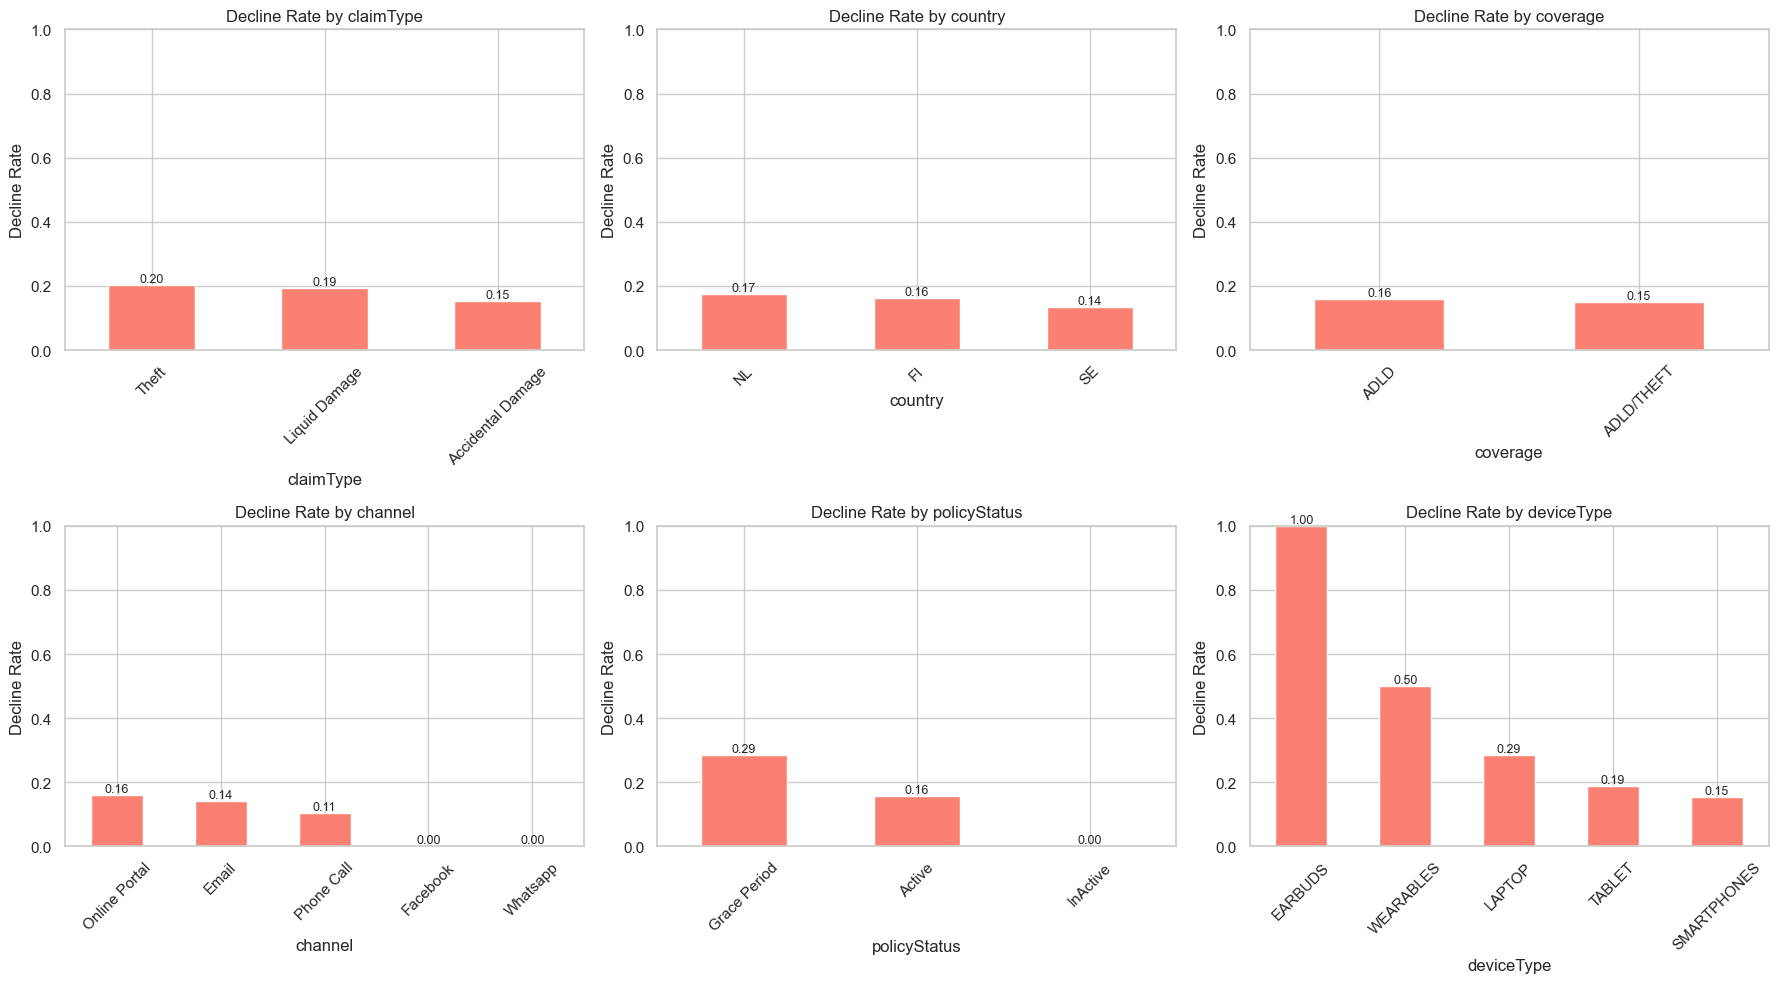

In [9]:
# Decline rate by key categorical features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

key_cats = ['claimType', 'country', 'coverage', 'channel', 'policyStatus', 'deviceType']

for ax, col in zip(axes.flat, key_cats):
    # Compute decline rate per category
    ct = pd.crosstab(df_raw[col], df_raw['status'], normalize='index')
    if 'Declined' in ct.columns:
        decline_rate = ct['Declined'].sort_values(ascending=False)
    else:
        continue
    decline_rate.plot(kind='bar', ax=ax, color='salmon')
    ax.set_title(f'Decline Rate by {col}')
    ax.set_ylabel('Decline Rate')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)
    # Add value labels
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [10]:
# Status breakdown by country and claim type
ct = pd.crosstab([df_raw['country'], df_raw['claimType']], df_raw['status'], margins=True)
ct['decline_rate'] = (ct['Declined'] / (ct['Completed'] + ct['Declined'])).round(4)
ct

status                     Completed  Declined   All  decline_rate
country claimType                                                 
FI      Accidental Damage        105        22   127        0.1732
        Liquid Damage              6         0     6        0.0000
        Theft                      3         0     3        0.0000
NL      Accidental Damage       1187       252  1439        0.1751
        Liquid Damage             32        10    42        0.2381
        Theft                     47         5    52        0.0962
SE      Accidental Damage       1003       146  1149        0.1271
        Liquid Damage             16         3    19        0.1579
        Theft                     28        15    43        0.3488
All                             2427       453  2880        0.1573

---
## 5. Numerical Feature Analysis

In [11]:
num_cols = ['excessFee', 'rrp', 'balanceRRP', 'oldBalanceRRP', 'deviceCost']

df_raw[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
excessFee,2874.0,387.070633,446.548065,0.00,59.0,139.0,619.0,3629.0
rrp,2880.0,6926.282556,7300.148073,0.00,1349.0,1799.0,14490.0,43888.0
balanceRRP,2880.0,6781.947028,7214.160287,-4861.33,1349.0,1799.0,13990.0,43888.0
oldBalanceRRP,2880.0,6781.947028,7214.160287,-4861.33,1349.0,1799.0,13990.0,43888.0
deviceCost,2880.0,0.000000,0.000000,0.00,0.0,0.0,0.0,0.0


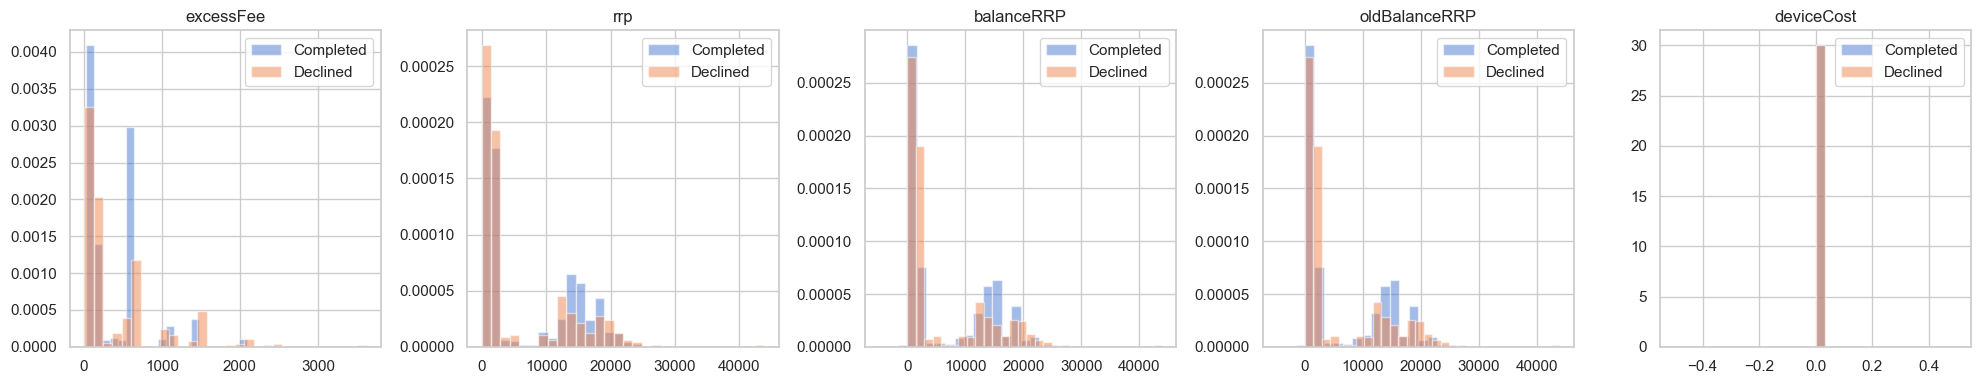

In [12]:
# Distribution of numerical features by status
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4))

for ax, col in zip(axes, num_cols):
    for status in ['Completed', 'Declined']:
        subset = df_raw[df_raw['status'] == status][col].dropna()
        ax.hist(subset, bins=30, alpha=0.5, label=status, density=True)
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

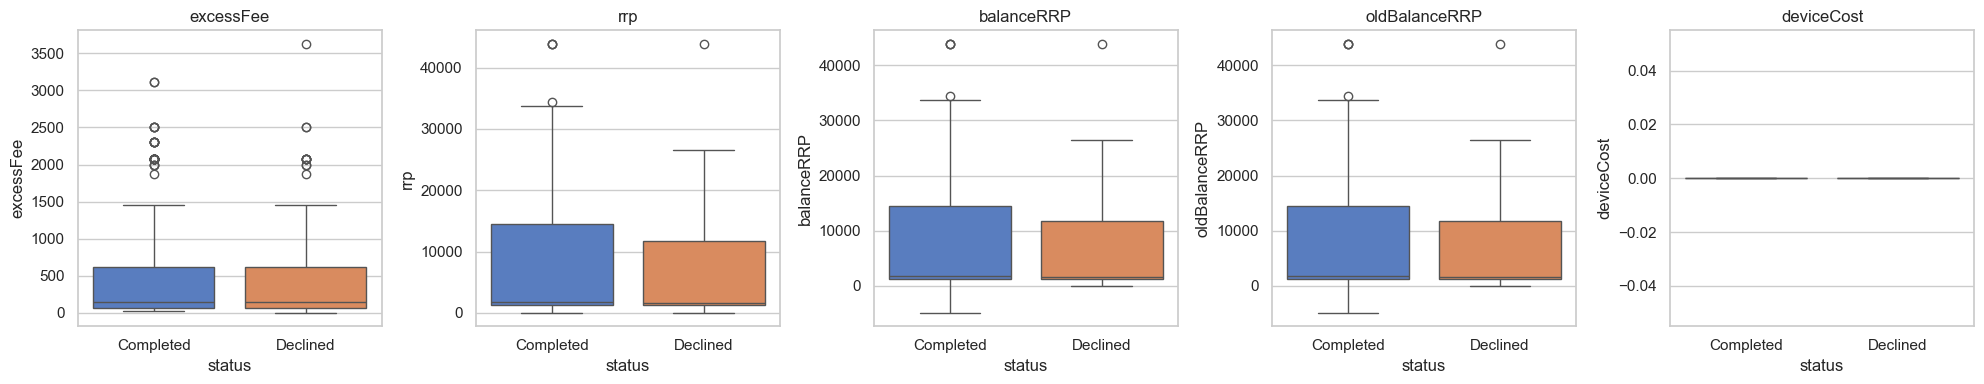

In [13]:
# Box plots: numerical features by status
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4))

for ax, col in zip(axes, num_cols):
    sns.boxplot(x='status', y=col, data=df_raw, ax=ax, hue='status', legend=False)
    ax.set_title(col)

plt.tight_layout()
plt.show()

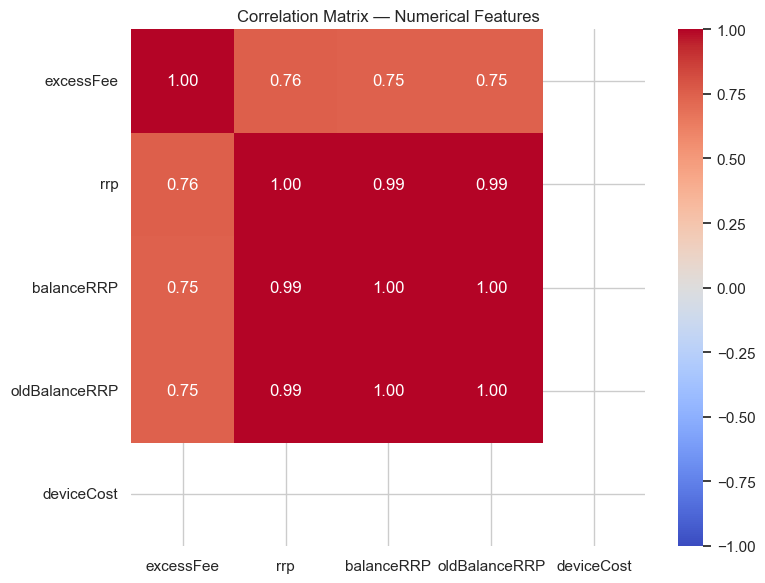

In [14]:
# Correlation heatmap of numerical features
fig, ax = plt.subplots(figsize=(8, 6))
corr = df_raw[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()

---
## 6. Boolean/Device Condition Features

In [15]:
bool_cols = ['turnOnOff', 'touchScreen', 'smashed', 'frontCamera', 'backCamera',
             'frontOrBackCamera', 'audio', 'mic', 'buttons', 'connection', 'charging', 'other']

print('Value counts for boolean columns:')
for col in bool_cols:
    print(f'\n--- {col} ---')
    print(df_raw[col].value_counts(dropna=False))

Value counts for boolean columns:

--- turnOnOff ---
turnOnOff
1.0    2361
0.0     315
NaN     204
Name: count, dtype: int64

--- touchScreen ---
touchScreen
0.0    1490
1.0    1187
NaN     203
Name: count, dtype: int64

--- smashed ---
smashed
NaN    1877
0.0    1003
Name: count, dtype: int64

--- frontCamera ---
frontCamera
1.0    2234
0.0     424
NaN     222
Name: count, dtype: int64

--- backCamera ---
backCamera
1.0    2198
0.0     460
NaN     222
Name: count, dtype: int64

--- frontOrBackCamera ---
frontOrBackCamera
NaN    1877
0.0    1003
Name: count, dtype: int64

--- audio ---
audio
1.0    2293
0.0     365
NaN     222
Name: count, dtype: int64

--- mic ---
mic
1.0    2276
0.0     382
NaN     222
Name: count, dtype: int64

--- buttons ---
buttons
0.0    2652
NaN     221
1.0       7
Name: count, dtype: int64

--- connection ---
connection
0.0    2202
NaN     677
1.0       1
Name: count, dtype: int64

--- charging ---
charging
0.0    2202
NaN     677
1.0       1
Name: count, dtyp

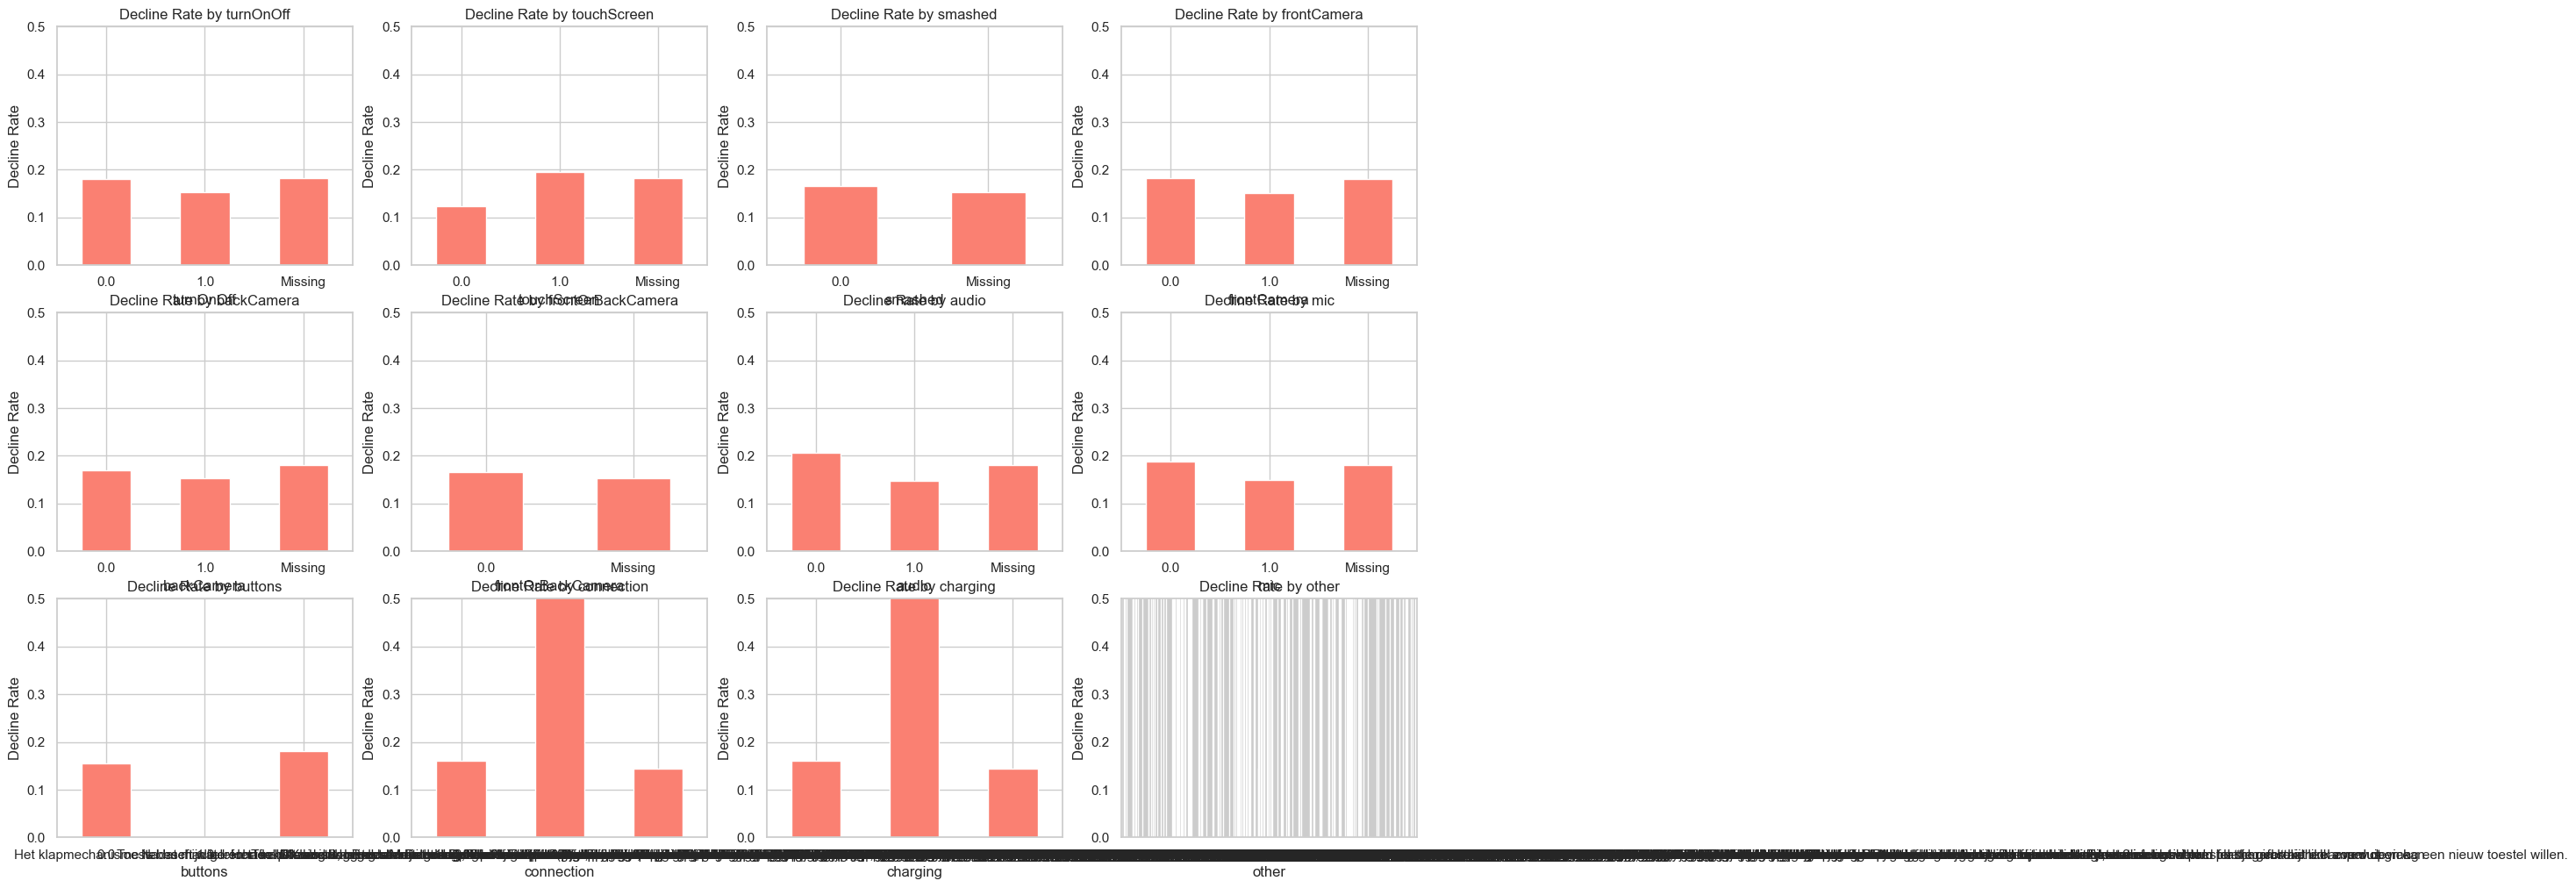

In [16]:
# Decline rate by boolean device condition features
fig, axes = plt.subplots(3, 4, figsize=(20, 12))

for ax, col in zip(axes.flat, bool_cols):
    ct = pd.crosstab(df_raw[col].fillna('Missing'), df_raw['status'], normalize='index')
    if 'Declined' in ct.columns:
        ct['Declined'].plot(kind='bar', ax=ax, color='salmon')
    ax.set_title(f'Decline Rate by {col}')
    ax.set_ylabel('Decline Rate')
    ax.set_ylim(0, 0.5)
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## 7. Date & Policy Features

In [17]:
# Parse dates — handle mixed formats
date_cols = ['policyStartDate', 'policyEndDate', 'purchaseDate']
for col in date_cols:
    df_raw[col] = pd.to_datetime(df_raw[col], format='mixed', dayfirst=True, errors='coerce')
    print(f'{col}: {df_raw[col].dtype}, nulls={df_raw[col].isnull().sum()}, '
          f'range=[{df_raw[col].min()} — {df_raw[col].max()}]')

policyStartDate: datetime64[us], nulls=0, range=[2021-12-15 00:00:00 — 2024-12-07 00:00:00]
policyEndDate: datetime64[us], nulls=0, range=[2022-12-15 00:00:00 — 2025-12-07 00:00:00]
purchaseDate: datetime64[us], nulls=0, range=[2021-12-15 00:00:00 — 2024-12-07 00:00:00]


In [18]:
# Derived: policy duration in days
df_raw['policy_duration_days'] = (df_raw['policyEndDate'] - df_raw['policyStartDate']).dt.days

# Derived: days from purchase to policy start
df_raw['purchase_to_policy_days'] = (df_raw['policyStartDate'] - df_raw['purchaseDate']).dt.days

print('policy_duration_days:')
print(df_raw['policy_duration_days'].describe())
print(f'\npurchase_to_policy_days:')
print(df_raw['purchase_to_policy_days'].describe())

policy_duration_days:
count    2880.000000
mean      418.513542
std       173.170532
min         6.000000
25%       365.000000
50%       365.000000
75%       366.000000
max       731.000000
Name: policy_duration_days, dtype: float64

purchase_to_policy_days:
count    2880.000000
mean       12.843750
std        72.614365
min      -260.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       366.000000
Name: purchase_to_policy_days, dtype: float64


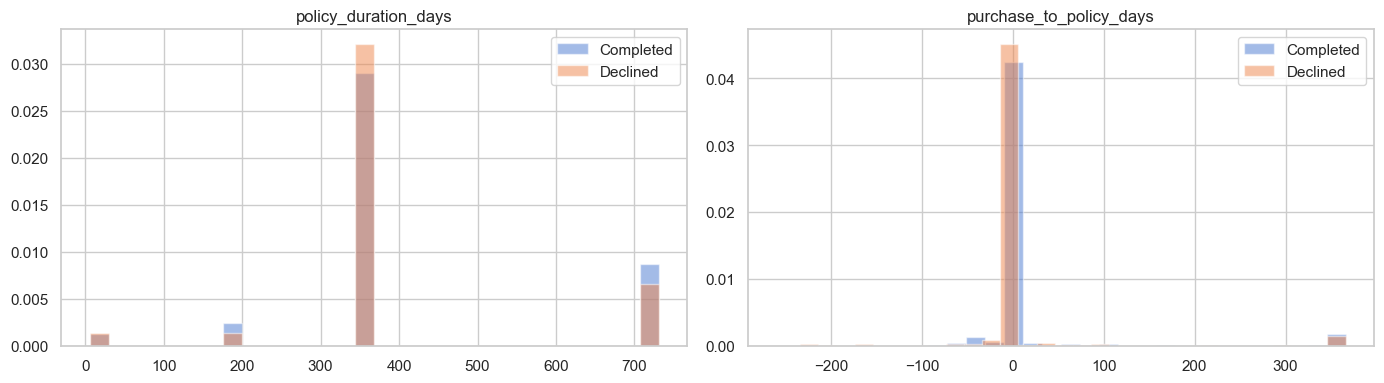

In [19]:
# Policy duration distribution by status
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col in zip(axes, ['policy_duration_days', 'purchase_to_policy_days']):
    for status in ['Completed', 'Declined']:
        subset = df_raw[df_raw['status'] == status][col].dropna()
        ax.hist(subset, bins=30, alpha=0.5, label=status, density=True)
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

---
## 8. Text Feature Analysis — `issueDesc`

In [20]:
# Basic text statistics
df_raw['desc_length'] = df_raw['issueDesc'].fillna('').str.len()
df_raw['desc_word_count'] = df_raw['issueDesc'].fillna('').str.split().str.len()

print('Description length stats:')
print(df_raw[['desc_length', 'desc_word_count']].describe())

Description length stats:
       desc_length  desc_word_count
count  2880.000000      2880.000000
mean    263.595486        44.699653
std     179.172528        30.737418
min      56.000000         4.000000
25%     172.000000        29.000000
50%     205.000000        36.000000
75%     285.000000        49.000000
max    2638.000000       446.000000


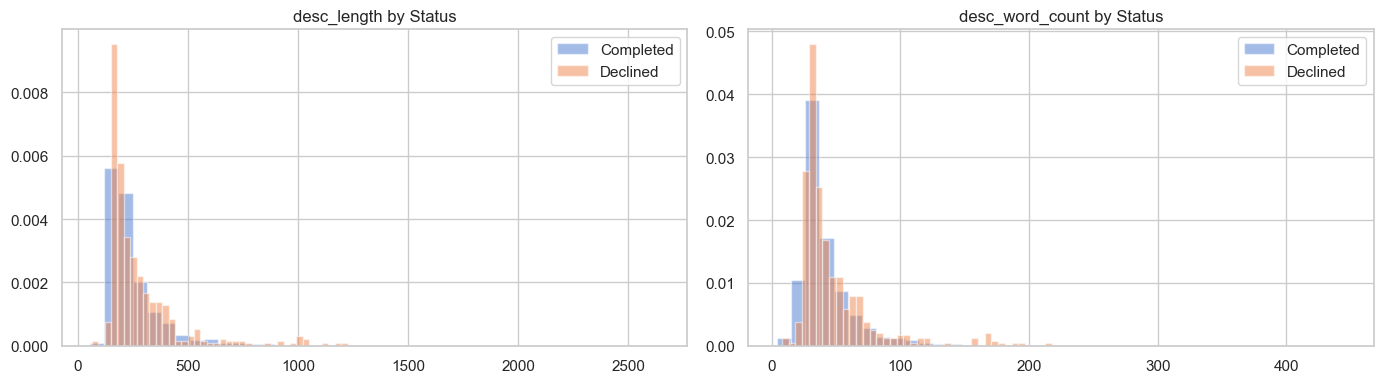

In [21]:
# Text length by status
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col in zip(axes, ['desc_length', 'desc_word_count']):
    for status in ['Completed', 'Declined']:
        subset = df_raw[df_raw['status'] == status][col].dropna()
        ax.hist(subset, bins=40, alpha=0.5, label=status, density=True)
    ax.set_title(f'{col} by Status')
    ax.legend()

plt.tight_layout()
plt.show()

In [22]:
# Compare mean text stats by status
print('Mean text stats by status:')
print(df_raw.groupby('status')[['desc_length', 'desc_word_count']].mean().round(1))

Mean text stats by status:
           desc_length  desc_word_count
status                                 
Completed        260.5             44.2
Declined         280.3             47.6


In [23]:
# Check how many descriptions contain redacted PII (***)
df_raw['has_redacted_pii'] = df_raw['issueDesc'].fillna('').str.contains(r'\*{3,}').astype(int)
print(f'Claims with redacted PII: {df_raw["has_redacted_pii"].sum()} / {len(df_raw)} '
      f'({df_raw["has_redacted_pii"].mean():.1%})')

Claims with redacted PII: 2719 / 2880 (94.4%)


In [24]:
# Sample declined claims — look for patterns
print('=== Sample DECLINED claim descriptions ===')
declined_samples = df_raw[df_raw['status'] == 'Declined']['issueDesc'].sample(10, random_state=42)
for i, desc in enumerate(declined_samples):
    print(f'\n[{i+1}] {desc[:300]}...' if len(str(desc)) > 300 else f'\n[{i+1}] {desc}')

=== Sample DECLINED claim descriptions ===

[1] Ik zag vanochtend dat er krassen op mijn scherm zitten. Ik merkte eerder al dat de vingerafdruk scanner steeds slechter werkt. Ook *** opladen gaat vaak niet goed.

[2] ******** .*** anvÃ¤nde senast telefonen pÃ¥ krogen . *** 22/1 .\nTelefonen var borta efter *** gick *** frÃ¥n en middag ,vet ej om *** fÃ¶rsvann pÃ¥ **** ***** pÃ¥ bussen .

[3] Telefoon lag op *** kast. **** ik telefoon pakte stond hij op *** WUAWEI Galaxy begin scherm. Proberen *** te zetten en opnieuw op te starten maar **** doet ***. 

[4] Hey beeldscherm is beschadigd en de lak bij de s-pen is afgebladderd. *** toestel werkt verder nog wel. **** idee *** *** is gebeurd. Graag reparatie 

[5] Mobilen blir varm **** tiden vÃ¤ldigt hÃ¶gvÃ¤rme vet ej vad det beror Ã¤ven nÃ¤r *** laddas upp sÃ¥ kÃ¤nner *** en vÃ¤ldigt hÃ¶g vÃ¤rme det gÃ¶r att *** **** vÃ¥gar anvÃ¤nda mobilen rÃ¤tt pga vÃ¤rmen 

[6] Ik kwam net thuis *** *** *****, drukke *** op werk en wou mijn telefoon ui

In [25]:
# Sample completed claims — for comparison
print('=== Sample COMPLETED claim descriptions ===')
completed_samples = df_raw[df_raw['status'] == 'Completed']['issueDesc'].sample(5, random_state=42)
for i, desc in enumerate(completed_samples):
    print(f'\n[{i+1}] {desc[:300]}...' if len(str(desc)) > 300 else f'\n[{i+1}] {desc}')

=== Sample COMPLETED claim descriptions ===

[1] ******* is ***** werkzaamheden met zwaar materiaal en palen zetten om *** land gevallen. Daardoor is *** toestel zo danig beschadigd dat *** **** **** doet en echt kapot is.\nHij is uit mijn *** gevallen. En daarna is *** **** erop gezet. Ik bukte om de **** te geleiden. En **** gebeurde *** allemaa...

[2] Ik (contractant) heb zelf *** toestel gebruikt. Al bellend deed ik de voordeur open **** ik thuis kwam. Onze enthousiaste **** sprong ***** mij op waar door *** toestel uit mijn hand viel. Ondanks de bumper op *** toestel is op *** of andere manier toch *** scherm kapot gegaan.

[3] Op oudjaars avond om **** is bij ons in ******** voor mijn deur *** vuurwerk explosie geweest. Is overal in *** nieuws geweest. Op dat moment had mijn vriendin mijn WUAWEI S23 ultra bij haar. Ze stond midden in de explosie en is door de druk en de knallen door de deur in de gang gevallen in *** glas...

[4] Mijn telefoon lag op de **** *** mijn bank. Mijn 

---
## 9. Data Cleaning

In [26]:
df = df_raw.copy()
print(f'Starting shape: {df.shape}')

Starting shape: (2880, 40)


In [27]:
# 9.1 Encode target variable
df['target'] = (df['status'] == 'Completed').astype(int)  # 1 = Approved, 0 = Declined
print(f'Target distribution:\n{df["target"].value_counts()}')

Target distribution:
target
1    2427
0     453
Name: count, dtype: int64


In [28]:
# 9.2 Clean boolean columns — convert to numeric (1/0/NaN)
for col in bool_cols:
    df[col] = df[col].map({True: 1, False: 0, 'True': 1, 'False': 0})
    
print('Boolean columns after cleaning:')
df[bool_cols].describe().T[['count', 'mean']]

Boolean columns after cleaning:


,count,mean
turnOnOff,2676.0,0.882287
touchScreen,2677.0,0.443407
smashed,1003.0,0.000000
frontCamera,2658.0,0.840482
backCamera,2658.0,0.826938
frontOrBackCamera,1003.0,0.000000
audio,2658.0,0.862679
mic,2658.0,0.856283
buttons,2659.0,0.002633
connection,2203.0,0.000454


In [29]:
# 9.3 Handle deviceType nulls — infer from productName/productCode where possible
print(f'deviceType nulls before: {df["deviceType"].isnull().sum()}')

# If productName or productCode contains SMARTPHONE/TABLET/etc., fill deviceType
def infer_device_type(row):
    if pd.notna(row['deviceType']):
        return row['deviceType']
    product_str = str(row.get('productName', '')) + ' ' + str(row.get('productCode', ''))
    product_str = product_str.upper()
    if 'SMARTPHONE' in product_str:
        return 'SMARTPHONES'
    elif 'TABLET' in product_str:
        return 'TABLET'
    elif 'LAPTOP' in product_str:
        return 'LAPTOP'
    elif 'WEARABLE' in product_str or 'WATCH' in product_str:
        return 'WEARABLES'
    elif 'EARBUD' in product_str:
        return 'EARBUDS'
    return 'UNKNOWN'

df['deviceType'] = df.apply(infer_device_type, axis=1)
print(f'deviceType nulls after: {df["deviceType"].isnull().sum()}')
print(df['deviceType'].value_counts())

deviceType nulls before: 1394
deviceType nulls after: 0
deviceType
SMARTPHONES    2698
TABLET           80
WEARABLES        51
LAPTOP           50
EARBUDS           1
Name: count, dtype: int64


In [30]:
# 9.4 Fill missing excessFee with median per coverage type
print(f'excessFee nulls before: {df["excessFee"].isnull().sum()}')
df['excessFee'] = df.groupby('coverage')['excessFee'].transform(
    lambda x: x.fillna(x.median())
)
print(f'excessFee nulls after: {df["excessFee"].isnull().sum()}')

excessFee nulls before: 6
excessFee nulls after: 0


In [31]:
# 9.5 Handle boolean column NaNs
# These are likely missing because they weren't assessed (e.g., theft claims don't have device condition checks)
# Strategy: fill with -1 to indicate "not assessed" — this preserves the signal that data is missing
for col in bool_cols:
    null_count = df[col].isnull().sum()
    if null_count > 0:
        df[col] = df[col].fillna(-1).astype(int)

print('Boolean columns after NaN handling:')
for col in bool_cols:
    print(f'  {col}: {df[col].value_counts().to_dict()}')

Boolean columns after NaN handling:
  turnOnOff: {1: 2361, 0: 315, -1: 204}
  touchScreen: {0: 1490, 1: 1187, -1: 203}
  smashed: {-1: 1877, 0: 1003}
  frontCamera: {1: 2234, 0: 424, -1: 222}
  backCamera: {1: 2198, 0: 460, -1: 222}
  frontOrBackCamera: {-1: 1877, 0: 1003}
  audio: {1: 2293, 0: 365, -1: 222}
  mic: {1: 2276, 0: 382, -1: 222}
  buttons: {0: 2652, -1: 221, 1: 7}
  connection: {0: 2202, -1: 677, 1: 1}
  charging: {0: 2202, -1: 677, 1: 1}
  other: {-1: 2880}


---
## 10. Feature Engineering

In [32]:
# 10.1 Financial features
df['excess_to_rrp_ratio'] = df['excessFee'] / df['rrp'].replace(0, np.nan)
df['balance_change'] = df['balanceRRP'] - df['oldBalanceRRP']
df['has_balance_change'] = (df['balance_change'] != 0).astype(int)

print('Financial features:')
print(df[['excess_to_rrp_ratio', 'balance_change', 'has_balance_change']].describe().T)

Financial features:
                      count     mean       std  min       25%       50%  \
excess_to_rrp_ratio  2877.0  0.07587  0.127347  0.0  0.037365  0.044731   
balance_change       2880.0  0.00000  0.000000  0.0  0.000000  0.000000   
has_balance_change   2880.0  0.00000  0.000000  0.0  0.000000  0.000000   

                          75%       max  
excess_to_rrp_ratio  0.088092  1.843373  
balance_change       0.000000  0.000000  
has_balance_change   0.000000  0.000000  


In [33]:
# 10.2 Device condition score — count of working components
condition_cols = ['turnOnOff', 'touchScreen', 'frontCamera', 'backCamera',
                  'audio', 'mic', 'buttons', 'connection', 'charging']

# Only count where value is 1 (working) — ignore -1 (not assessed) and 0 (not working)
df['device_condition_score'] = df[condition_cols].apply(
    lambda row: (row == 1).sum(), axis=1
)
df['device_issues_count'] = df[condition_cols].apply(
    lambda row: (row == 0).sum(), axis=1
)
df['device_not_assessed_count'] = df[condition_cols].apply(
    lambda row: (row == -1).sum(), axis=1
)

print('Device condition features:')
print(df[['device_condition_score', 'device_issues_count', 'device_not_assessed_count']].describe().T)

Device condition features:
                            count      mean       std  min  25%  50%  75%  max
device_condition_score     2880.0  4.360417  2.096979  0.0  4.0  5.0  6.0  7.0
device_issues_count        2880.0  3.643056  2.117351  0.0  3.0  3.0  4.0  9.0
device_not_assessed_count  2880.0  0.996528  2.381908  0.0  0.0  0.0  0.0  9.0


In [34]:
# 10.3 Text-based features from issueDesc
df['desc_length'] = df['issueDesc'].fillna('').str.len()
df['desc_word_count'] = df['issueDesc'].fillna('').str.split().str.len()
df['desc_sentence_count'] = df['issueDesc'].fillna('').str.count(r'[.!?]+') + 1
df['desc_has_newlines'] = df['issueDesc'].fillna('').str.contains(r'\n').astype(int)
df['desc_uppercase_ratio'] = (
    df['issueDesc'].fillna('').str.count(r'[A-Z]') /
    df['issueDesc'].fillna('x').str.len()
).fillna(0)
df['desc_exclamation_count'] = df['issueDesc'].fillna('').str.count('!')
df['desc_question_count'] = df['issueDesc'].fillna('').str.count(r'\?')
df['has_redacted_pii'] = df['issueDesc'].fillna('').str.contains(r'\*{3,}').astype(int)

print('Text features:')
print(df[['desc_length', 'desc_word_count', 'desc_sentence_count',
           'desc_uppercase_ratio', 'desc_exclamation_count']].describe().T)

Text features:
                         count        mean         std   min        25%  \
desc_length             2880.0  263.595486  179.172528  56.0  172.00000   
desc_word_count         2880.0   44.699653   30.737418   4.0   29.00000   
desc_sentence_count     2880.0    3.820486    2.179843   1.0    3.00000   
desc_uppercase_ratio    2880.0    0.011837    0.010939   0.0    0.00578   
desc_exclamation_count  2880.0    0.049653    0.961557   0.0    0.00000   

                               50%         75%          max  
desc_length             205.000000  285.000000  2638.000000  
desc_word_count          36.000000   49.000000   446.000000  
desc_sentence_count       4.000000    5.000000    31.000000  
desc_uppercase_ratio      0.010204    0.014925     0.165517  
desc_exclamation_count    0.000000    0.000000    49.000000  


In [35]:
# 10.4 Policy features (already partially created)
df['policy_duration_days'] = (df['policyEndDate'] - df['policyStartDate']).dt.days
df['purchase_to_policy_days'] = (df['policyStartDate'] - df['purchaseDate']).dt.days

# Is the policy still active?
df['is_policy_active'] = (df['policyStatus'] == 'Active').astype(int)

# Claim month and day-of-week from policyStartDate (proxy for claim date)
df['policy_start_month'] = df['policyStartDate'].dt.month
df['policy_start_dayofweek'] = df['policyStartDate'].dt.dayofweek

print('Policy features:')
print(df[['policy_duration_days', 'purchase_to_policy_days',
           'is_policy_active', 'policy_start_month']].describe().T)

Policy features:
                          count        mean         std    min    25%    50%  \
policy_duration_days     2880.0  418.513542  173.170532    6.0  365.0  365.0   
purchase_to_policy_days  2880.0   12.843750   72.614365 -260.0    0.0    0.0   
is_policy_active         2880.0    0.989236    0.103207    0.0    1.0    1.0   
policy_start_month       2880.0    5.662847    3.271846    1.0    3.0    6.0   

                           75%    max  
policy_duration_days     366.0  731.0  
purchase_to_policy_days    0.0  366.0  
is_policy_active           1.0    1.0  
policy_start_month         8.0   12.0  


In [36]:
# 10.5 Categorical encoding — label encode low-cardinality, frequency encode high-cardinality
from sklearn.preprocessing import LabelEncoder

# Low cardinality — label encode
label_encode_cols = ['coverage', 'claimType', 'country', 'channel', 'relationship', 'deviceType']

label_encoders = {}
for col in label_encode_cols:
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col].fillna('UNKNOWN').astype(str))
    label_encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

coverage: {'ADLD': np.int64(0), 'ADLD/THEFT': np.int64(1)}
claimType: {'Accidental Damage': np.int64(0), 'Liquid Damage': np.int64(1), 'Theft': np.int64(2)}
country: {'FI': np.int64(0), 'NL': np.int64(1), 'SE': np.int64(2)}
channel: {'Email': np.int64(0), 'Facebook': np.int64(1), 'Online Portal': np.int64(2), 'Phone Call': np.int64(3), 'Whatsapp': np.int64(4)}
relationship: {'self': np.int64(0)}
deviceType: {'EARBUDS': np.int64(0), 'LAPTOP': np.int64(1), 'SMARTPHONES': np.int64(2), 'TABLET': np.int64(3), 'WEARABLES': np.int64(4)}


In [37]:
# High cardinality — frequency encode
freq_encode_cols = ['productCode', 'retailerName', 'model']

for col in freq_encode_cols:
    freq = df[col].value_counts(normalize=True)
    df[f'{col}_freq'] = df[col].map(freq).fillna(0)
    print(f'{col}_freq — min: {df[f"{col}_freq"].min():.4f}, max: {df[f"{col}_freq"].max():.4f}')

productCode_freq — min: 0.0000, max: 0.0998
retailerName_freq — min: 0.0000, max: 0.7134
model_freq — min: 0.0003, max: 0.0514


In [38]:
# 10.6 Interaction features
# Excess fee relative to device RRP, segmented by claim type
df['excess_rrp_by_claimtype'] = df.groupby('claimType')['excess_to_rrp_ratio'].transform('mean')

# Country-level decline rate (target encoding — use with care to avoid leakage)
# We'll compute this on train set only during modelling, but show the concept here
df['country_decline_rate'] = df.groupby('country')['target'].transform('mean')
df['claimType_decline_rate'] = df.groupby('claimType')['target'].transform('mean')

print('Interaction features sample:')
df[['country', 'claimType', 'country_decline_rate', 'claimType_decline_rate',
    'excess_rrp_by_claimtype']].drop_duplicates().head(10)

Interaction features sample:


,country,claimType,country_decline_rate,claimType_decline_rate,excess_rrp_by_claimtype
0,SE,Theft,0.864575,0.795918,0.104962
1,SE,Accidental Damage,0.864575,0.845304,0.075054
25,SE,Liquid Damage,0.864575,0.805970,0.066364
1211,NL,Accidental Damage,0.825832,0.845304,0.075054
1223,NL,Theft,0.825832,0.795918,0.104962
1268,NL,Liquid Damage,0.825832,0.805970,0.066364
2744,FI,Accidental Damage,0.838235,0.845304,0.075054
2746,FI,Liquid Damage,0.838235,0.805970,0.066364
2775,FI,Theft,0.838235,0.795918,0.104962


> **Note on target encoding:** The `country_decline_rate` and `claimType_decline_rate` features above are computed on the full dataset for demonstration. In the actual modelling pipeline, these must be computed only on the training fold to prevent data leakage.

---
## 11. Feature Summary & Selection

In [39]:
# Define final feature set
feature_cols = [
    # Financial
    'excessFee', 'rrp', 'balanceRRP', 'oldBalanceRRP', 'deviceCost',
    'excess_to_rrp_ratio', 'balance_change', 'has_balance_change',
    
    # Device condition
    'device_condition_score', 'device_issues_count', 'device_not_assessed_count',
    *bool_cols,
    
    # Text
    'desc_length', 'desc_word_count', 'desc_sentence_count',
    'desc_has_newlines', 'desc_uppercase_ratio',
    'desc_exclamation_count', 'desc_question_count', 'has_redacted_pii',
    
    # Policy
    'policy_duration_days', 'purchase_to_policy_days',
    'is_policy_active', 'policy_start_month', 'policy_start_dayofweek',
    
    # Encoded categoricals
    'coverage_encoded', 'claimType_encoded', 'country_encoded',
    'channel_encoded', 'relationship_encoded', 'deviceType_encoded',
    
    # Frequency encoded
    'productCode_freq', 'retailerName_freq', 'model_freq',
]

print(f'Total features: {len(feature_cols)}')
print(f'\nFeature list:')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i:2d}. {col}')

Total features: 45

Feature list:
   1. excessFee
   2. rrp
   3. balanceRRP
   4. oldBalanceRRP
   5. deviceCost
   6. excess_to_rrp_ratio
   7. balance_change
   8. has_balance_change
   9. device_condition_score
  10. device_issues_count
  11. device_not_assessed_count
  12. turnOnOff
  13. touchScreen
  14. smashed
  15. frontCamera
  16. backCamera
  17. frontOrBackCamera
  18. audio
  19. mic
  20. buttons
  21. connection
  22. charging
  23. other
  24. desc_length
  25. desc_word_count
  26. desc_sentence_count
  27. desc_has_newlines
  28. desc_uppercase_ratio
  29. desc_exclamation_count
  30. desc_question_count
  31. has_redacted_pii
  32. policy_duration_days
  33. purchase_to_policy_days
  34. is_policy_active
  35. policy_start_month
  36. policy_start_dayofweek
  37. coverage_encoded
  38. claimType_encoded
  39. country_encoded
  40. channel_encoded
  41. relationship_encoded
  42. deviceType_encoded
  43. productCode_freq
  44. retailerName_freq
  45. model_freq


In [40]:
# Check for remaining NaNs in feature columns
nan_check = df[feature_cols].isnull().sum()
nan_check = nan_check[nan_check > 0]
if len(nan_check) > 0:
    print('Features with remaining NaNs:')
    print(nan_check)
else:
    print('No NaNs remaining in feature columns.')

Features with remaining NaNs:
excess_to_rrp_ratio    3
dtype: int64


In [41]:
# Fill any remaining NaNs with 0 (safe default for the computed features)
df[feature_cols] = df[feature_cols].fillna(0)

# Final check
print(f'Final dataset shape: {df.shape}')
print(f'Feature matrix shape: {df[feature_cols].shape}')
print(f'Target distribution: {df["target"].value_counts().to_dict()}')
print(f'Any NaNs in features: {df[feature_cols].isnull().any().any()}')

Final dataset shape: (2880, 67)
Feature matrix shape: (2880, 45)
Target distribution: {1: 2427, 0: 453}
Any NaNs in features: False


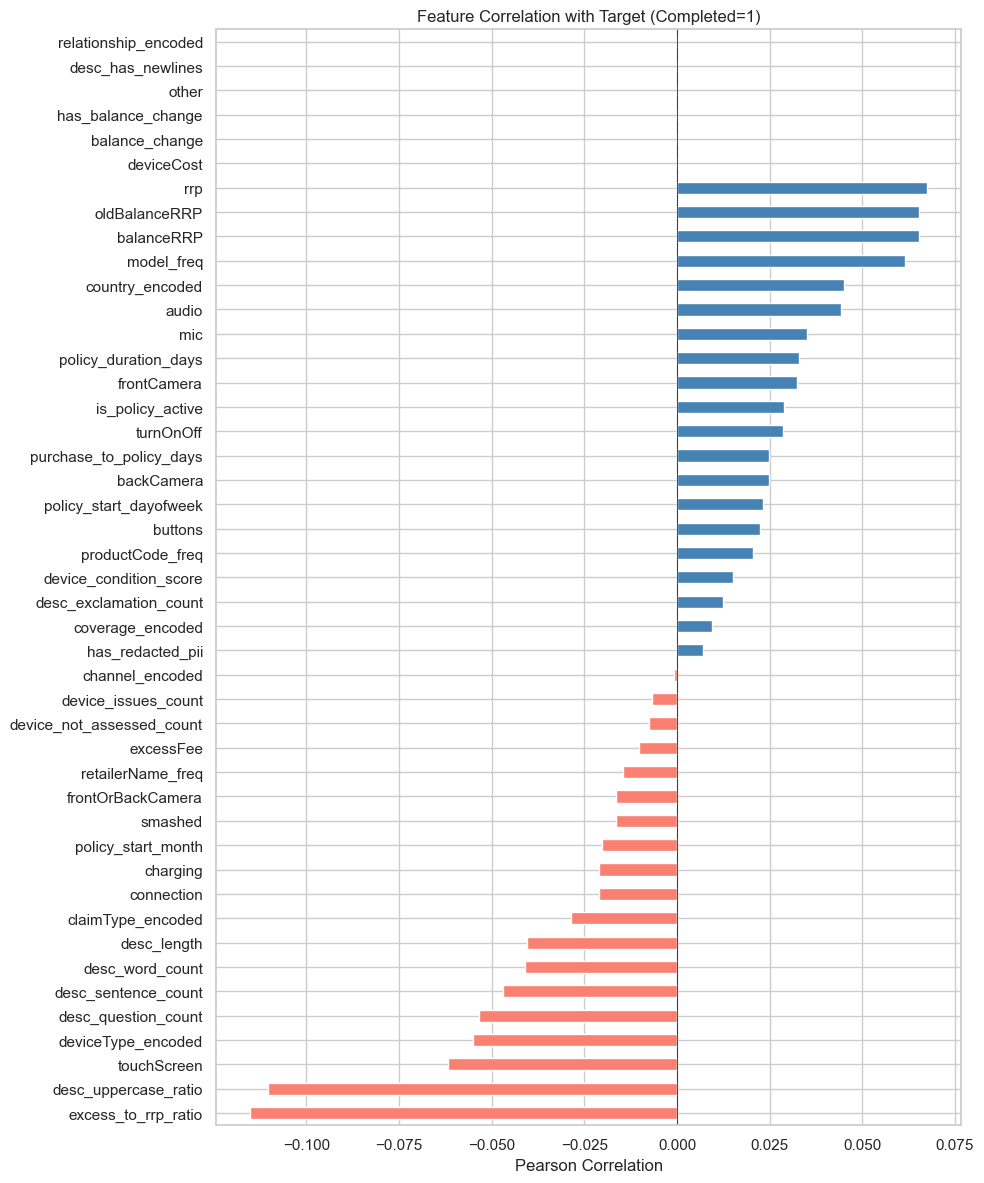

In [42]:
# Feature correlation with target
correlations = df[feature_cols + ['target']].corr()['target'].drop('target').sort_values()

fig, ax = plt.subplots(figsize=(10, 12))
correlations.plot(kind='barh', ax=ax, color=correlations.apply(lambda x: 'salmon' if x < 0 else 'steelblue'))
ax.set_title('Feature Correlation with Target (Completed=1)')
ax.set_xlabel('Pearson Correlation')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

---
## 12. Save Cleaned Data

In [43]:
# Save the cleaned dataset with all features
output_path = Path('../../data')
output_path.mkdir(exist_ok=True)

# Full cleaned dataset
df.to_csv(output_path / 'claims_cleaned.csv', index=False)
print(f'Saved cleaned dataset to {output_path / "claims_cleaned.csv"}')

# Feature matrix + target only (for direct ML use)
df_ml = df[feature_cols + ['target']].copy()
df_ml.to_csv(output_path / 'claims_features.csv', index=False)
print(f'Saved feature matrix to {output_path / "claims_features.csv"}')

# Save feature column list
with open(output_path / 'feature_columns.txt', 'w') as f:
    f.write('\n'.join(feature_cols))
print(f'Saved feature column list to {output_path / "feature_columns.txt"}')

print(f'\nFinal shapes:')
print(f'  Full cleaned: {df.shape}')
print(f'  ML-ready:     {df_ml.shape}')

Saved cleaned dataset to ..\..\data\claims_cleaned.csv
Saved feature matrix to ..\..\data\claims_features.csv
Saved feature column list to ..\..\data\feature_columns.txt

Final shapes:
  Full cleaned: (2880, 67)
  ML-ready:     (2880, 46)


---
## Takeaways

Main things I noticed:
- 84/16 class split, pretty imbalanced. Need to handle this in modelling
- A bunch of columns are basically useless (deviceCost is all zeros, balanceRRP == oldBalanceRRP everywhere, smashed is always 0)
- The boolean device condition columns have ~47% missing. But that's actually useful info since theft claims dont have device diagnostics
- rrp, balanceRRP, oldBalanceRRP are super correlated, keep one
- The text descriptions are multilingual (Swedish/Dutch/Finnish/English) and heavily redacted with ***

Ended up with 45 engineered features across financial, device condition, text stats, policy, and encoded categoricals. Saved everything to `data/` for the modelling step.